In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
#from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import os

sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.model
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0610 09:59:55.138690 140672495048512 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
from platform import python_version

print(python_version())
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Reshape, Flatten, BatchNormalization, Conv2D, Conv3D, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda,  concatenate
import tensorflow_probability as tfp

3.6.8


In [3]:
######## Parameters
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Load data

In [4]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band

In [5]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [6]:
images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

In [7]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
np.where(np.isnan(data['e1_hsm_regauss']))

(array([ 341,  522, 1051, 1218, 2091, 2505, 3300, 3495, 3964, 4511, 4701,
        4866, 4898, 5517, 6098, 6357, 6399, 7265, 7533, 7863, 8096, 8223,
        8586, 8814]),)

In [8]:
np.where(np.isnan(data['e2_hsm_regauss']))

(array([ 341,  522, 1051, 1218, 2091, 2505, 3300, 3495, 3964, 4511, 4701,
        4866, 4898, 5517, 6098, 6357, 6399, 7265, 7533, 7863, 8096, 8223,
        8586, 8814]),)

In [9]:
len(np.where(np.isnan(data['e1_hsm_regauss']))[0])

24

In [10]:
np.where((data['e2_hsm_regauss']>1) | (data['e1_hsm_regauss']>1))

(array([  65,  172,  197,  204,  302,  386,  408,  507,  584,  613,  728,
         831,  845, 1025, 1085, 1115, 1231, 1266, 1301, 1306, 1346, 1474,
        1748, 1749, 1772, 1785, 1830, 1839, 1939, 1985, 1989, 1997, 2063,
        2076, 2255, 2519, 2535, 2552, 2671, 2753, 2794, 2859, 3038, 3076,
        3219, 3245, 3299, 3303, 3314, 3343, 3392, 3413, 3450, 3477, 3579,
        3600, 3613, 3674, 3723, 3790, 3841, 3871, 3872, 3935, 3980, 4021,
        4137, 4144, 4172, 4235, 4306, 4451, 4470, 4486, 4554, 4599, 4609,
        4637, 4986, 5009, 5120, 5153, 5161, 5377, 5493, 5502, 5577, 5629,
        5811, 5876, 5882, 5989, 6024, 6252, 6347, 6359, 6412, 6416, 6491,
        6494, 6554, 6583, 6591, 6652, 6691, 6712, 6804, 7050, 7094, 7110,
        7124, 7152, 7204, 7230, 7322, 7355, 7574, 7720, 7775, 7890, 8073,
        8140, 8359, 8418, 8485, 8542, 8749, 8969, 9004, 9005, 9014, 9083,
        9339, 9396, 9458, 9460, 9639, 9693, 9766, 9768, 9934]),)

In [11]:
len(np.where((data['e2_hsm_regauss']>1) | (data['e1_hsm_regauss']>1))[0])

141

In [12]:
141/10000

0.0141

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [14]:
data = data[data['blendedness']>0]
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data = data.dropna(axis = 0, how = 'any')

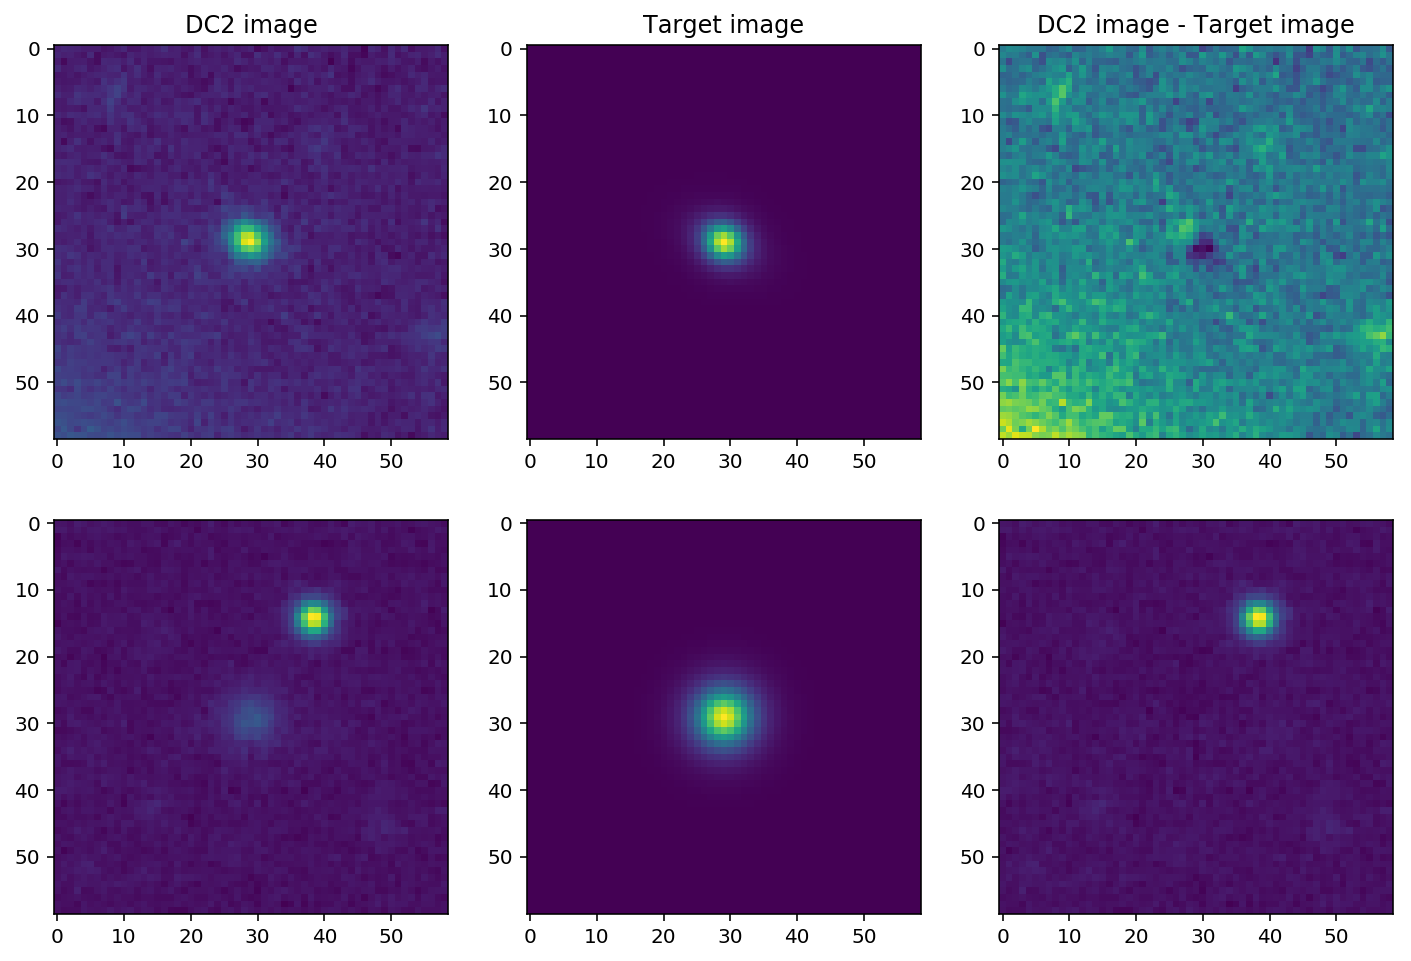

In [15]:
fig, axes = plt.subplots(2,3, figsize = (12, 8))

for i in range (2):
    axes[i,0].imshow(images_blend[i+3,:,:,2])
    axes[i,1].imshow(images_noiseless[i+3,:,:,2])
    axes[i,2].imshow(images_blend[i+3,:,:,2]- images_noiseless[i+3,:,:,2])
    
    if i == 0:
        axes[i,0].set_title('DC2 image')
        axes[i,1].set_title('Target image')
        axes[i,2].set_title('DC2 image - Target image')


In [16]:
images_blend = np.tanh(np.arcsinh(images_blend[:3000]))
images_noiseless = np.tanh(np.arcsinh(images_noiseless[:3000]))
psf = np.tanh(np.arcsinh(psf[:3000]))

### Test of trained VAE on noisy images

fig, axes = plt.subplots(10,4, figsize = (12, 40))


for i in range (10):
    plot.plot_rgb(images_blend_test_denorm[i], bands = [3,2,1],ax= axes[i,0], band_first= False,zoom = 1,)
    plot.plot_rgb(output_denorm[i], bands = [3,2,1],ax= axes[i,1], band_first= False,zoom = 1,)
    plot.plot_rgb(images_noiseless_test_denorm[i], bands = [3,2,1],ax= axes[i,2], band_first= False,zoom = 1,)
    plot.plot_rgb(images_blend_test_denorm[i]- output_denorm[i], bands = [3,2,1],ax= axes[i,3], band_first= False,zoom = 1,)
        
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('Prediction')
    axes[i,2].set_title('Target')
    axes[i,3].set_title('Blend - prediction')

### Param estimation from trained VAE

In [17]:
vae = model.create_model_wo_ls_peak_pooling_vae_4(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0610 10:00:45.211232 140672495048512 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0610 10:00:45.485127 140672495048512 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [18]:
encoder = Model([vae.layers[0].input,vae.layers[-2].input], vae.layers[20].output) #vae.layers[44].output[0]

In [19]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(32), scale=1.),reinterpreted_batch_ndims=1)


def param_estimation_net(vae, encoder, final_dim):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 
    
    encoder.trainable = False
    h = encoder([input_layer_1,input_layer_2])
    
    #h = tfp.layers.MultivariateNormalTriL(32,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.01))(tf.cast(h,tf.float32))

    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = None)(h)
    h = PReLU()(h)
    h = Dense(128, activation = None)(h)
    h = PReLU()(h)
    
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)
    
    return Model((input_layer_1, input_layer_2), h)

In [20]:
param_estim_net = param_estimation_net(vae, encoder, final_dim)

In [21]:
param_estim_net.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
model_1 (Model)                 (None, 560)          3741224     input_3[0][0]                    
                                                                 input_4[0][0]                    
__________________________________________________________________________________________________
dense_3 (Dense)                 (None, 256)          143616      model_1[1][0]              

In [22]:
loading_path = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_param_from_vae/end_step/'

In [23]:
latest = tf.train.latest_checkpoint(loading_path)
param_estim_net.load_weights(latest)

In [24]:
nb_of_points = 2000
indices = np.random.choice(data[:2000].index, size=nb_of_points, replace=False, p = None)

In [31]:
output = param_estim_net([tf.cast(images_blend[indices], tf.float32), tf.cast(psf[indices], tf.float32)])

mean = K.get_value(output.sample(1))[0]
std = K.get_value(output.stddev())
e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [32]:
batchsize = 10000

images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/'
saving_path = ''
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test/')) if x.startswith(os.path.join(images_dir,'test/')+'img_noiseless_sample')]#mag_24.5

training_generator = BatchGenerator_dc2_deconv_noisy_2(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None,
                                    net = param_estim_net,
                                    saving_path = saving_path,
                                    prop = 4,
                                    step_size = 10)

test = training_generator.__getitem__(3)

images_blend_test, psf_test = test[0]
param = test[1]

In [33]:
#fig, axes = plt.subplots(1,2, figsize = (10,4))
#_ = axes[0].hist(data['blendedness'], bins = 100, normed = True)
#axes[0].set_xscale('log')

#_ = axes[1].hist(param[:,2], bins = 100, normed = True)
#axes[1].set_xscale('log')

Text(0.5, 1.0, '$e2$')

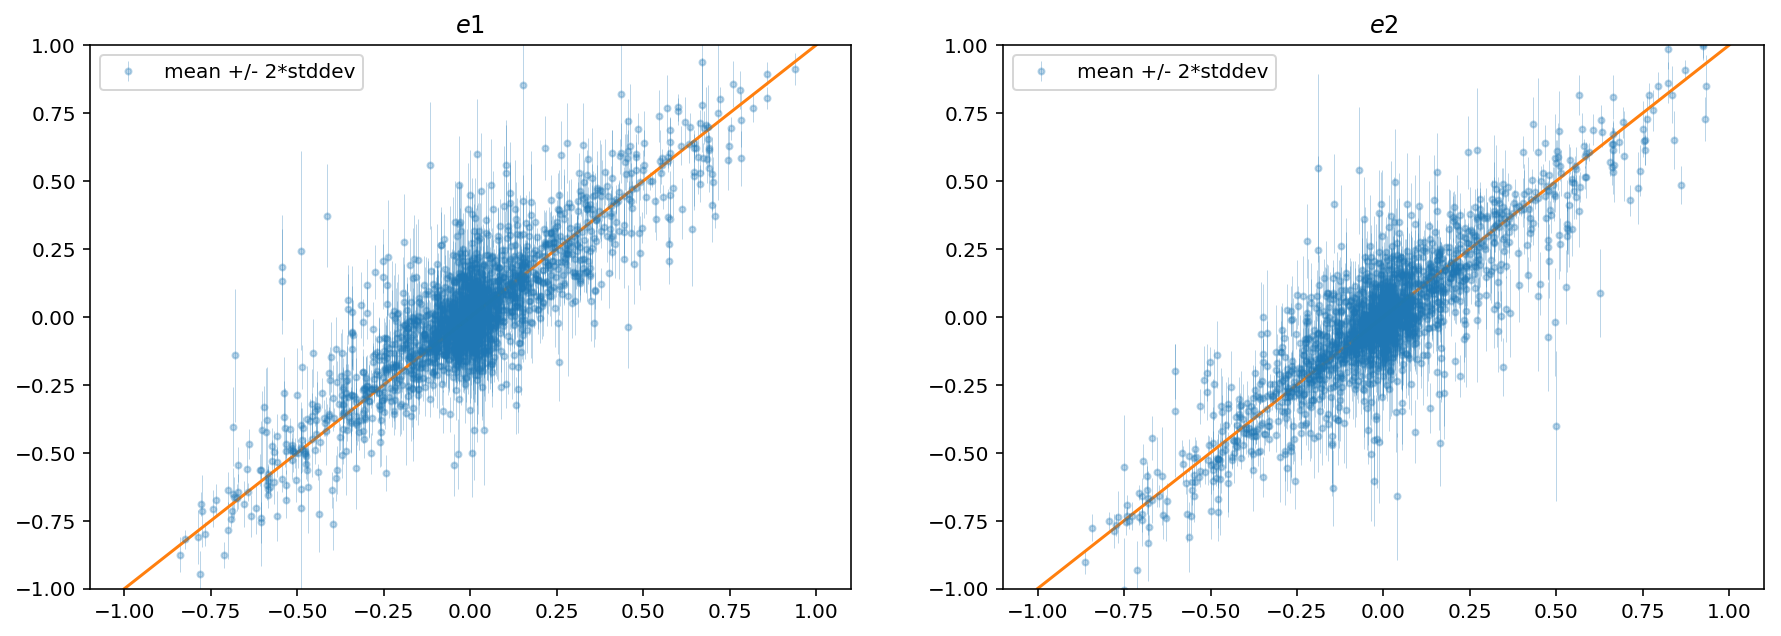

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(e1[indices], e1_out_mean, yerr = e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[indices], e2_out_mean, yerr = e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

Text(0.5, 0, '$e_2$ truth')

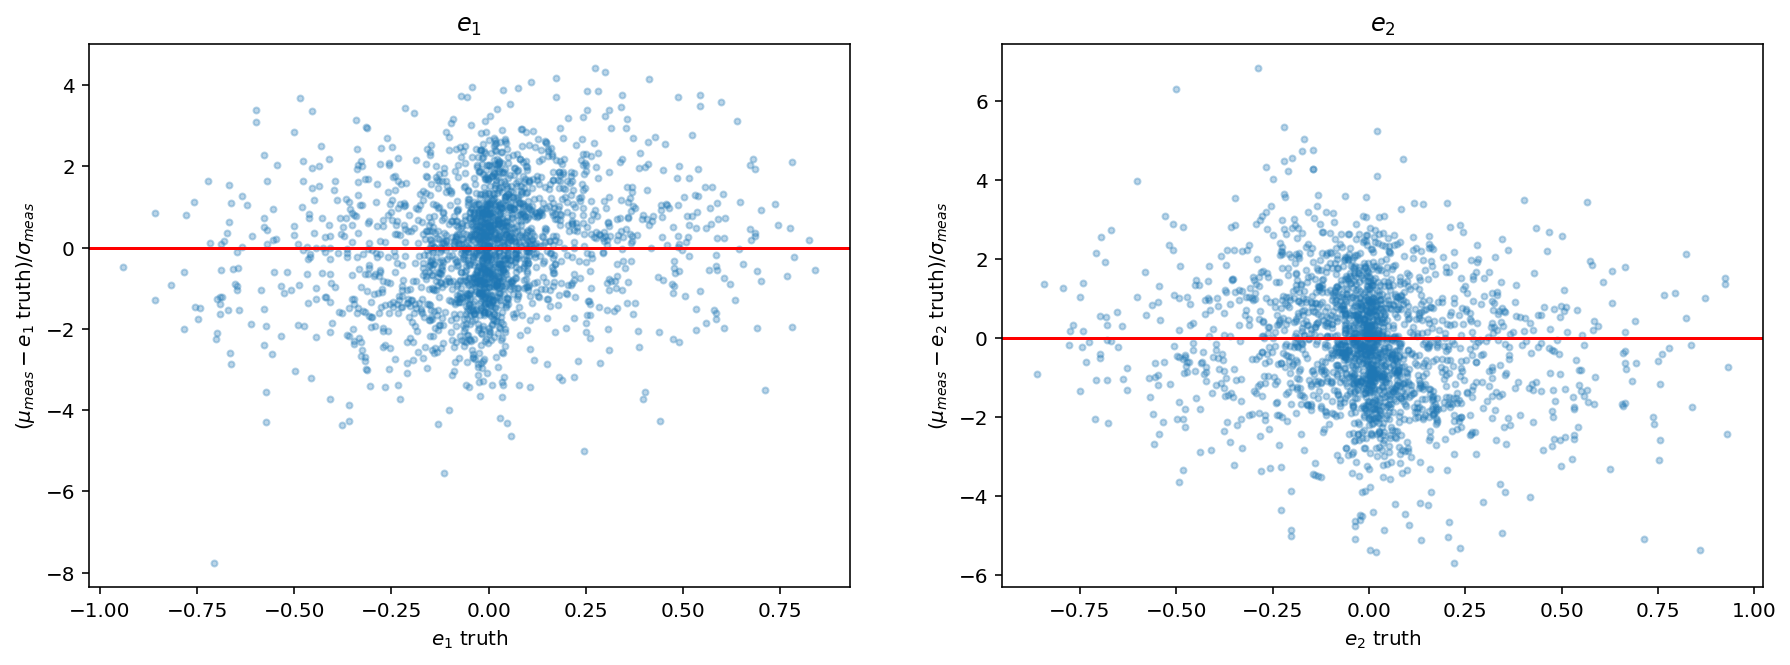

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(-e1[indices], (e1_out_mean-e1[indices])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[0].plot(x, x)
axes[0].axhline(0, color = 'r')
#axes[0].legend()
#axes[0].set_ylim(-1,1)
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')
#axes[0].set_xlim(-1.,1.)

axes[1].plot(e2[indices], (e2_out_mean-e2[indices])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
#x = np.linspace(-1,1)
#axes[1].plot(x, x)
#axes[1].legend()
axes[1].axhline(0, color = 'r')
#axes[1].set_ylim(-1,1)
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')

axes[1].set_xlabel('$e_2$ truth')

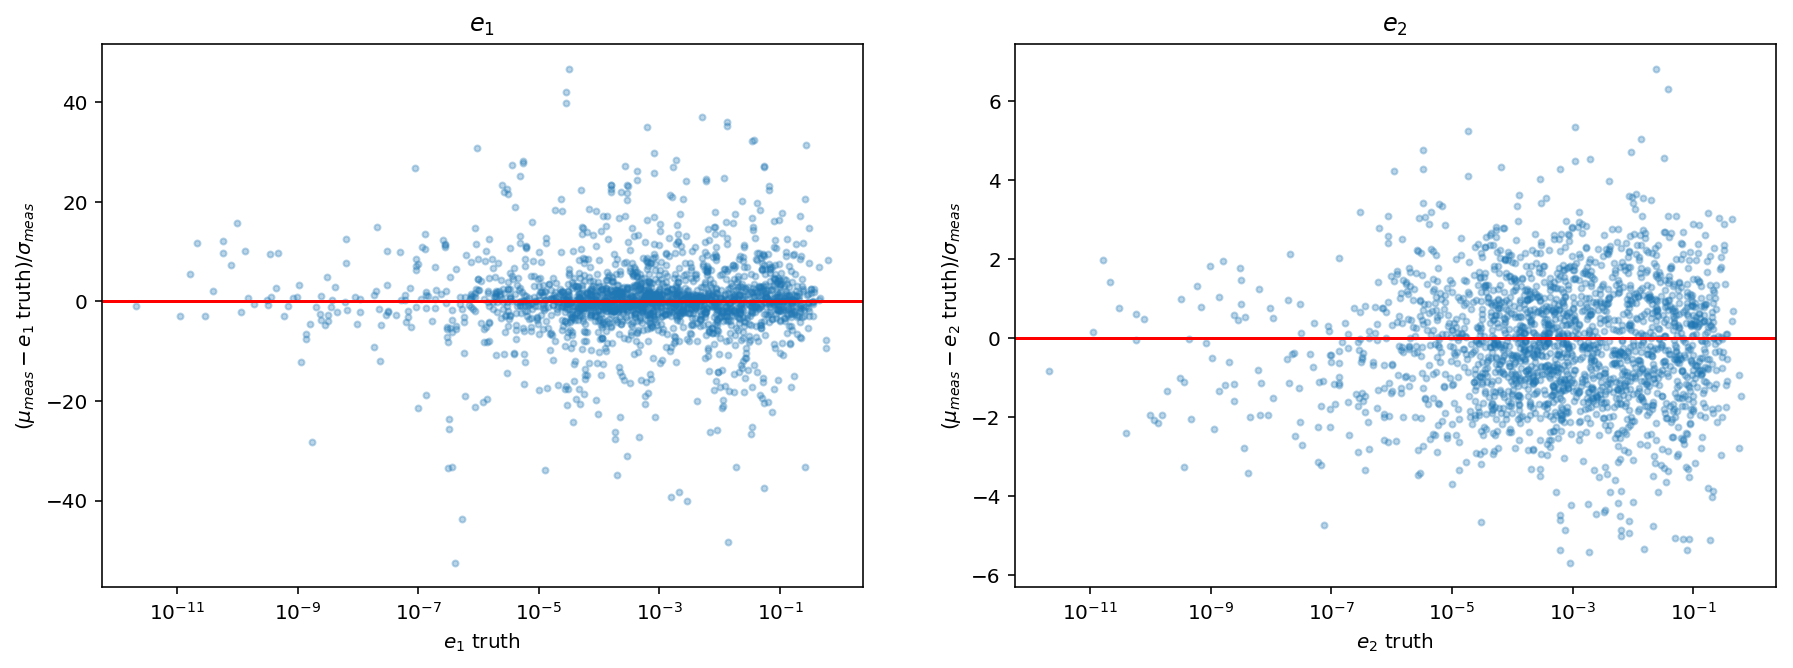

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices])/e1_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')
axes[0].set_xscale('log')

axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices])/e2_out_std, '.',label = 'mean +/- 2*stddev', alpha = 0.3)
axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')
axes[1].set_xlabel('$e_2$ truth')
axes[1].set_xscale('log')

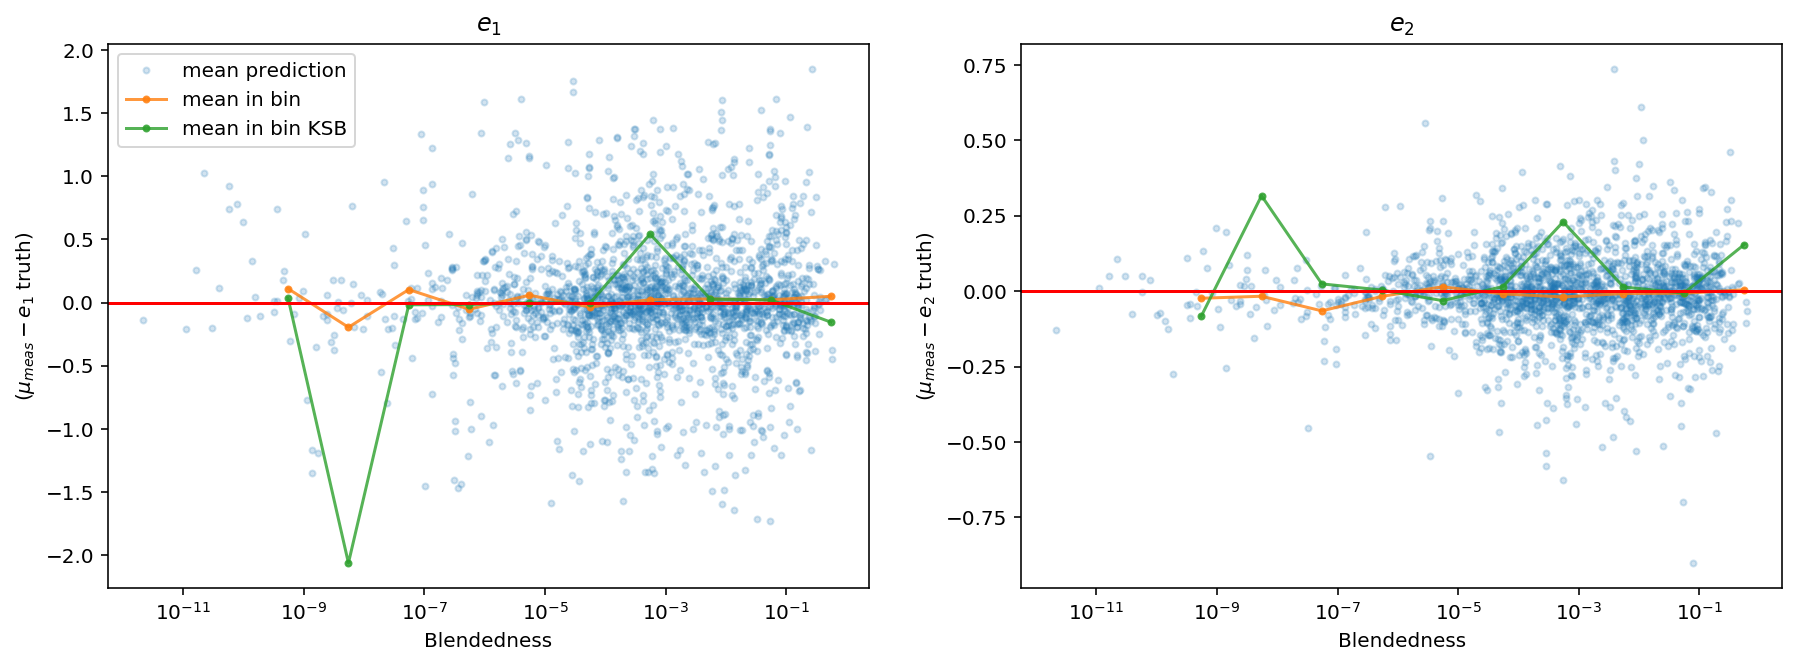

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin')

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin KSB')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

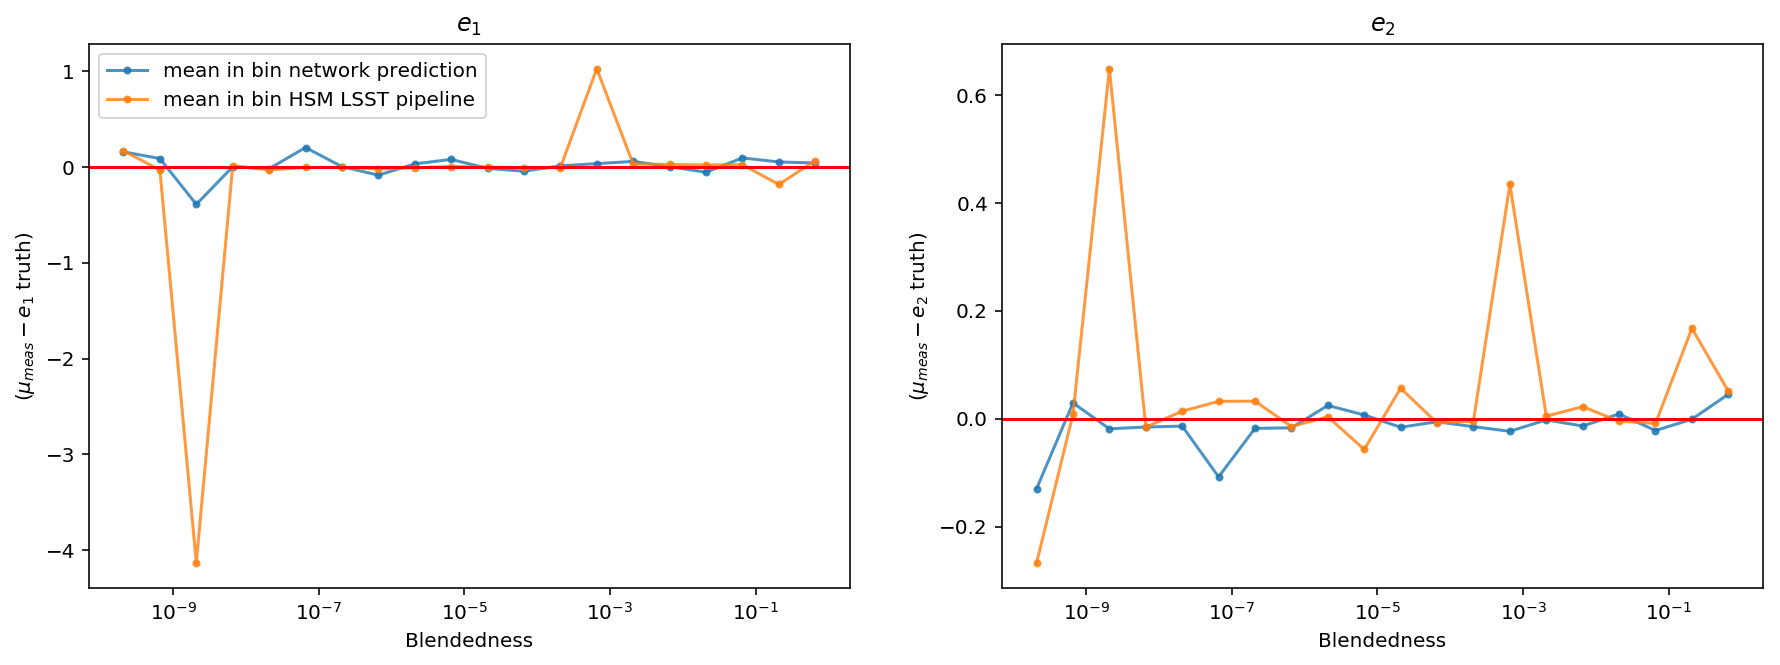

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
nbins = 20

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin network prediction')

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

In [39]:
images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

### Suppressing extrem prediction from HSM

In [40]:
new_data=data[(np.abs(data['e1_hsm_regauss'])<=1.) &
         (np.abs(data['e2_hsm_regauss'])<=1.)]

In [41]:
np.where((np.abs(data['e1_hsm_regauss'])>1.) &
         (np.abs(data['e2_hsm_regauss'])>1.) & (data.index<1000))

(array([408, 507, 728, 831]),)

In [42]:
len(new_data), len(data)

(9723, 10000)

In [43]:
nb_of_points = 2000
indices = np.random.choice(new_data[:2000].index, size=nb_of_points, replace=False, p = None)

In [44]:
output = param_estim_net([tf.cast(images_blend[indices], tf.float32), tf.cast(psf[indices], tf.float32)])

mean = K.get_value(output.sample(1))[0]
std = K.get_value(output.stddev())
e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

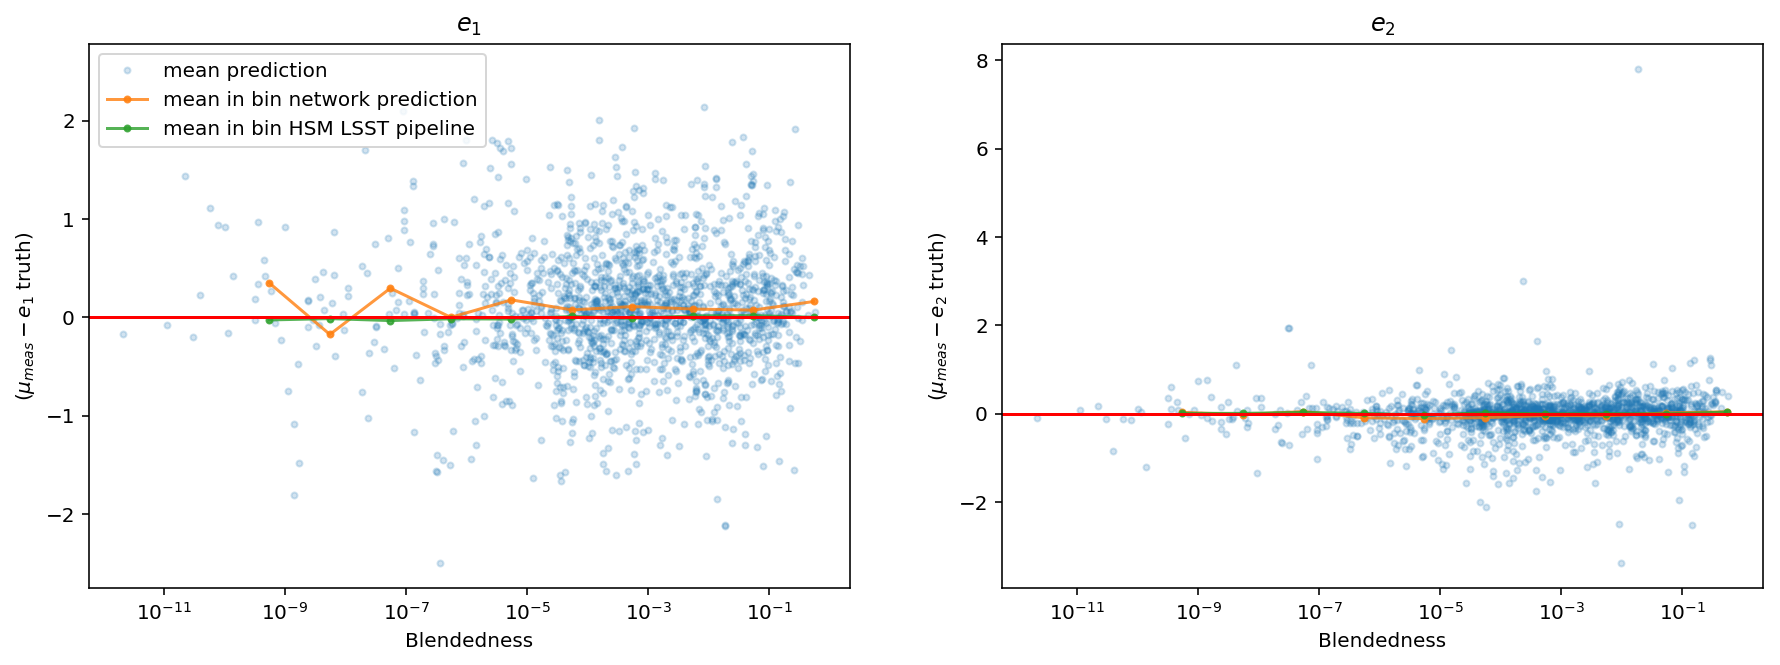

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin network prediction')

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')

bins=np.logspace(np.log10(1e-10),np.log10(1), 11)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(10)
for k in range(10):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

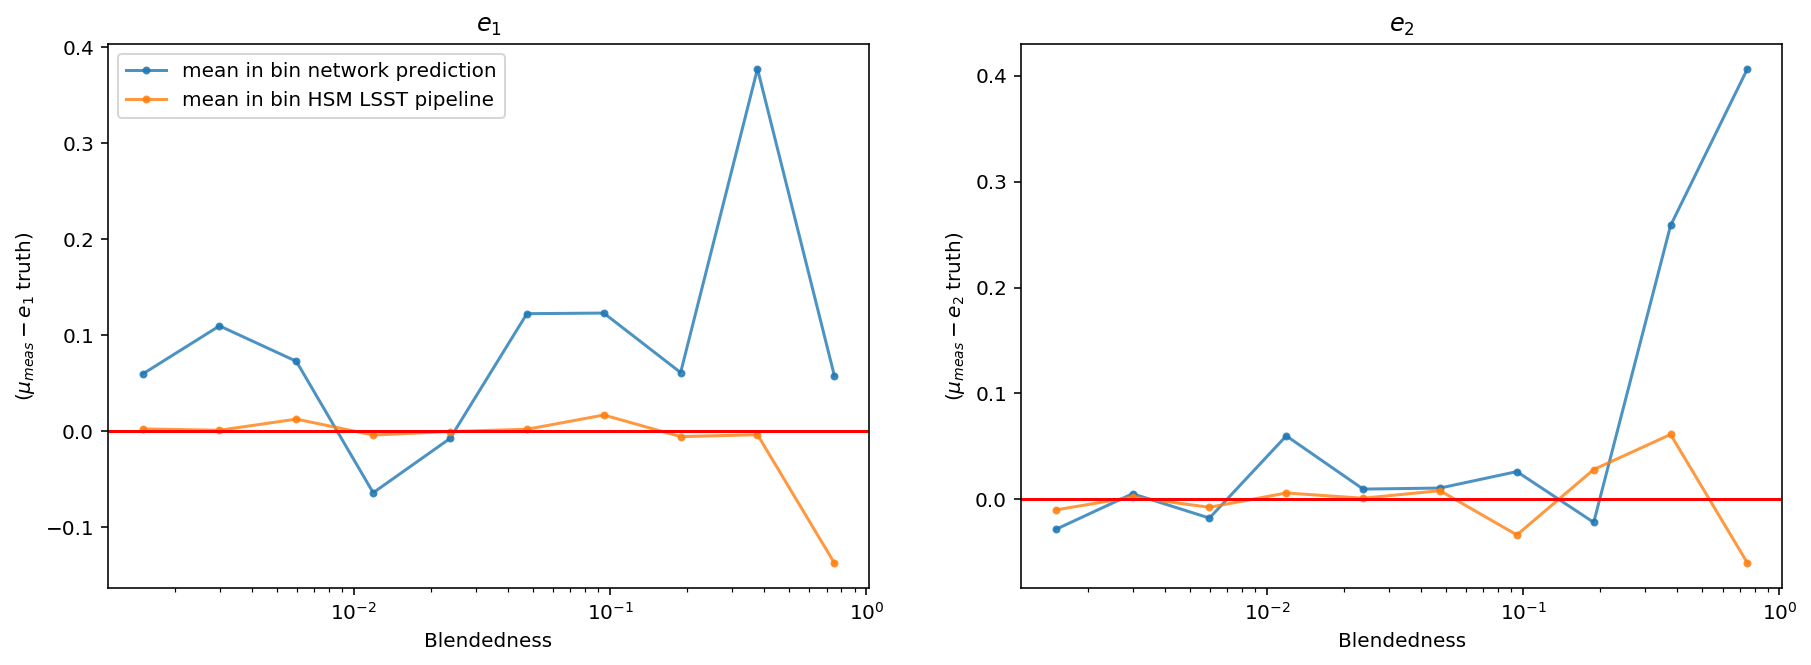

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
nbins = 10

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin network prediction')

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

In [47]:
e1_out_mean, e1[indices],data['e1_hsm_regauss'][indices]

(array([ 0.02199687, -0.35921192,  0.05630336, ...,  0.54212946,
         0.34363806,  0.9214916 ], dtype=float32),
 array([-0.13885407, -0.2257274 , -0.11145115, ...,  0.14450743,
         0.18595967,  0.24196341]),
 622    -0.095245
 970    -0.267570
 1503   -0.080990
 328    -0.214640
 1644   -0.126567
 1256   -0.075605
 1678    0.000734
 1093   -0.200669
 1471   -0.276167
 740     0.201666
 1801    0.209664
 224     0.114697
 1398    0.275424
 1497    0.204869
 1947    0.195426
 2002   -0.044149
 248     0.267098
 852     0.214954
 655    -0.067588
 30     -0.281718
 99      0.094035
 335    -0.302478
 1082    0.206259
 1049   -0.012226
 1321   -0.011466
 1177   -0.016594
 1194    0.157214
 1258    0.576696
 1186   -0.050650
 1614    0.100508
           ...   
 494     0.036047
 1273    0.036416
 1416   -0.047920
 1699    0.214769
 314     0.276312
 612     0.086854
 606     0.131181
 1097    0.023890
 1325   -0.056587
 1757   -0.077021
 722    -0.071029
 589     0.019450
 1095    

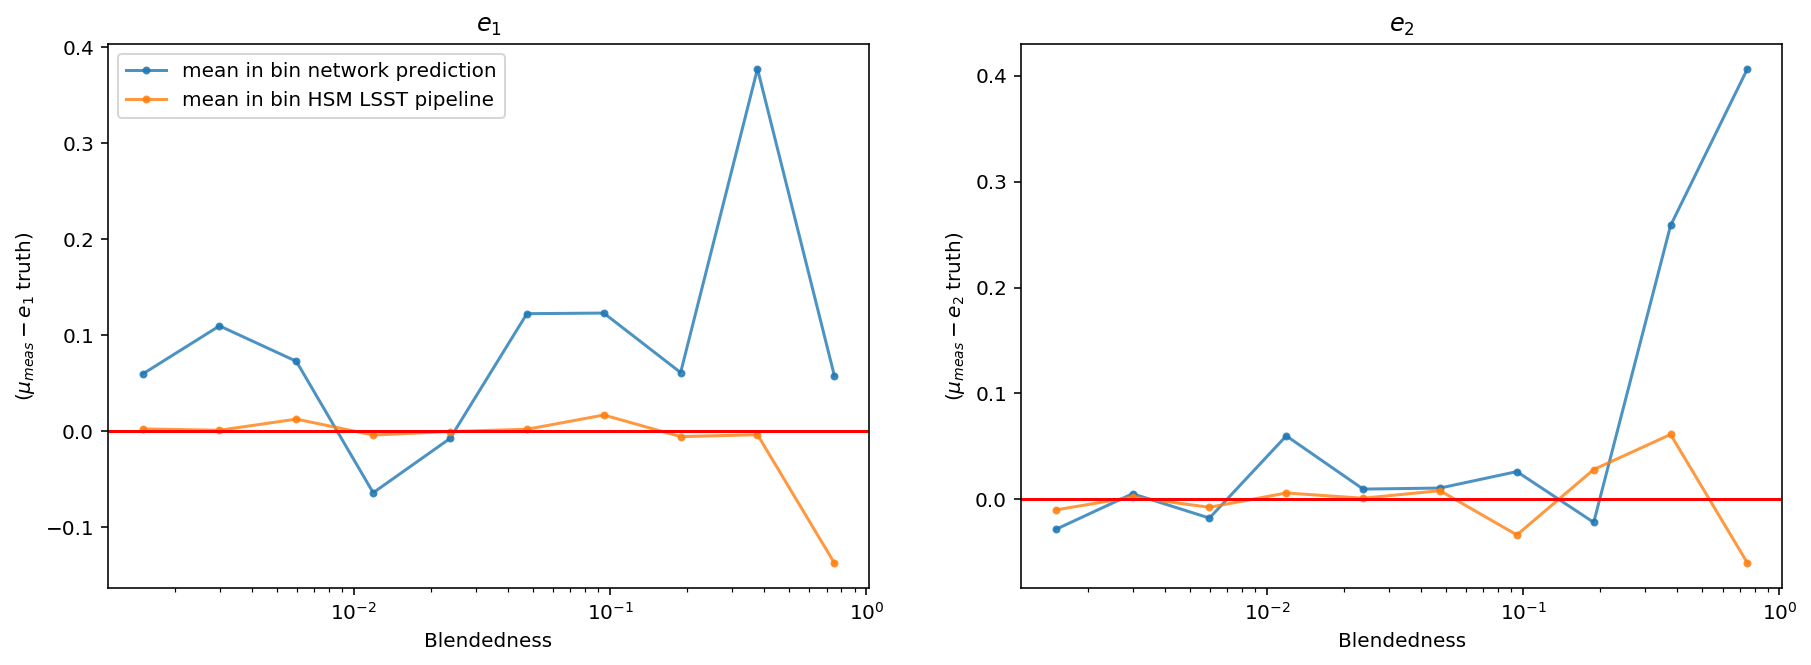

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
nbins = 10

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin network prediction')

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')

bins=np.logspace(np.log10(1e-3),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='median', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

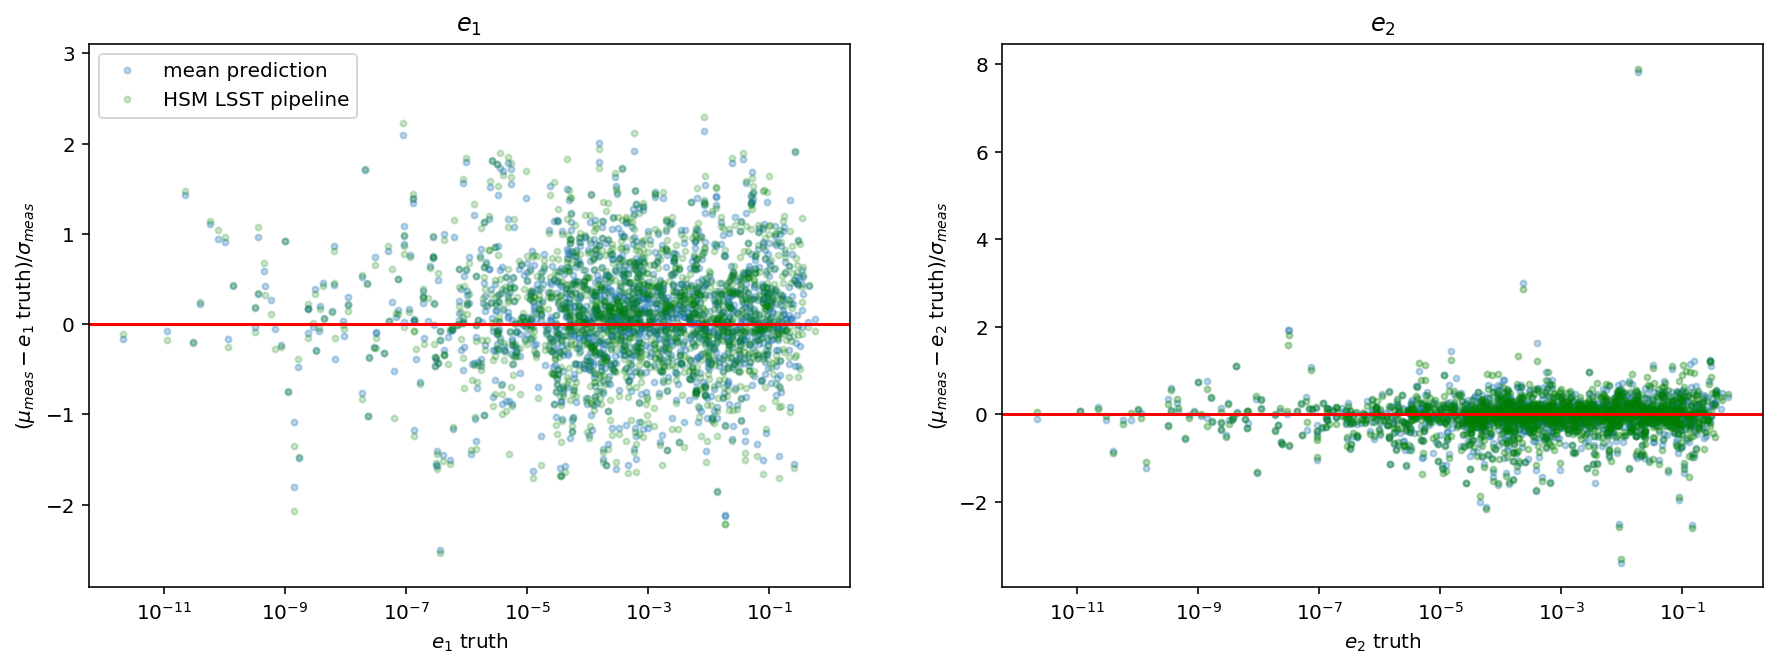

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.3)
axes[0].plot(data['blendedness'][indices], (e1_out_mean+data['e1_hsm_regauss'][indices]), '.', color = 'green',label = 'HSM LSST pipeline', alpha = 0.2)
axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)/$\sigma_{meas}$')
axes[0].set_xlabel('$e_1$ truth')
axes[0].set_xscale('log')

axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.3)
axes[1].plot(data['blendedness'][indices], (e2_out_mean-data['e2_hsm_regauss'][indices]), '.',color = 'green',label = 'HSM LSST pipeline', alpha = 0.3)
axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)/$\sigma_{meas}$')
axes[1].set_xlabel('$e_2$ truth')
axes[1].set_xscale('log')
axes[0].legend()

In [50]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = e1_out_mean
d['e2'] = e2_out_mean
d['e1_in'] = -e1[indices]
d['e2_in'] = e2[indices]
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss'][indices]], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss'][indices]], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss'][indices]**2+data['e2_hsm_regauss'][indices]**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'][indices],data['blendedness'][indices]], ignore_index = True)

df['exp'] = [1]*2000+[2]*2000

In [51]:
df

,e_1,e_2,e,e_in,e_error_reg,blendedness,exp
0,0.021997,-0.384445,0.385074,0.221492,0.163582,2.469988e-02,1
1,-0.359212,-0.766725,0.846700,0.225809,0.620891,2.100694e-03,1
2,0.056303,0.371188,0.375434,0.257462,0.117972,0.000000e+00,1
3,0.110882,1.134232,1.139639,0.849865,0.289774,3.454936e-01,1
4,-0.030523,-0.594369,0.595152,0.253583,0.341570,2.419668e-09,1
5,0.013416,0.033479,0.036067,0.028885,0.007183,1.706378e-02,1
6,0.305036,-0.839607,0.893302,0.190082,0.703219,3.126739e-05,1
7,-0.592359,-0.014031,0.592525,0.126688,0.465837,3.492190e-05,1
8,-0.247987,-0.729988,0.770960,0.587766,0.183194,4.723894e-03,1
9,0.362981,0.418692,0.554128,0.320642,0.233487,0.000000e+00,1


In [52]:
df_plot_2 = df[df['blendedness']>0]

3242
[1 2]
0 1
1 2


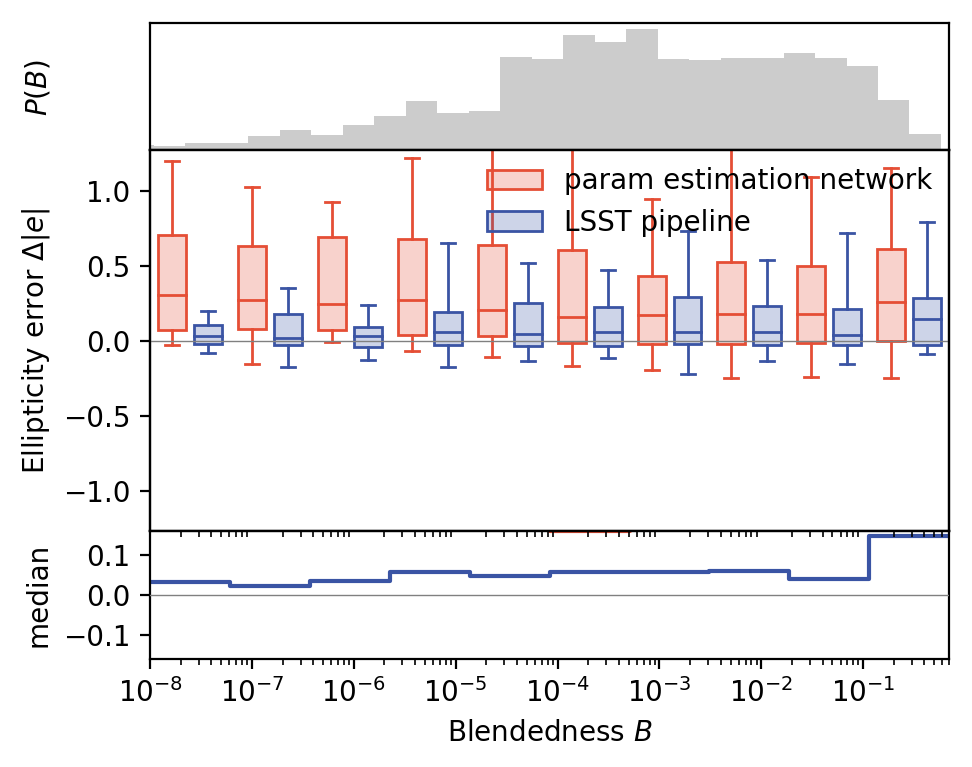

In [53]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_hsm.pdf')